# fix 1 - make sure low/med/high chunks for tone and time are being made properly

# fix 2 - legenmds are broken for sec 4

# fix 3 - make sure this logic is the same as prev intended

# fix 4 - find notes on how we wanted to generate the dataset, then make it for this

In [17]:
# # Install libraries
# !pip install torch torchaudio transformers librosa numpy pandas matplotlib seaborn scikit-learn pretty_midi

In [3]:
########################################
# Section 0 - Load models and libraries
########################################

# Install libraries
!pip install torch torchaudio transformers librosa numpy pandas matplotlib seaborn scikit-learn pretty_midi

import torch
import numpy as np
import pandas as pd
import librosa
import pretty_midi

from transformers import AutoModel, AutoProcessor

# Load MERT model
model_name = "m-a-p/MERT-v1-95M"

processor = AutoProcessor.from_pretrained(
    model_name,
    trust_remote_code=True
)

model = AutoModel.from_pretrained(
    model_name,
    trust_remote_code=True
)

model.eval()

print("MERT model loaded successfully")

Defaulting to user installation because normal site-packages is not writeable


configuration_MERT.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/m-a-p/MERT-v1-95M:
- configuration_MERT.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


modeling_MERT.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/m-a-p/MERT-v1-95M:
- modeling_MERT.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


pytorch_model.bin:   0%|          | 0.00/378M [00:00<?, ?B/s]

MERT model loaded successfully


In [7]:
##########################
# Section 1 - MIDI to audio
# MERT requires audio, so MIDI must be synthesized.
##########################

import pretty_midi
import librosa
import numpy as np

# Reference MIDI (true Fur Elise)
ref_midi_path = "MidiDatasets/590-Classical-music-midi/beeth/elise.mid"

# Input MIDIs to compare
input_midi_paths = [
    "MidiDatasets/TestingSamples/MidiOutputs/FurElise_2ndVerse_K-Amin_T-60_righthand.mid",
    "MidiDatasets/TestingSamples/MidiOutputs/FurElise_2ndVerse_K-Bmin_T-60_righthand.mid",
    "MidiDatasets/TestingSamples/MidiOutputs/FurElise_2ndVerse_K-Gmin_T-75_righthand.mid",
    "MidiDatasets/TestingSamples/MidiOutputs/FurElise_4thVerse_K-Amin_T-79_bothhands.mid",
    "MidiDatasets/TestingSamples/MidiOutputs/FurElise_4thVerse_K-Gmin_T-63_bothhands.mid",
    "MidiDatasets/TestingSamples/MidiOutputs/FurElise_Intro-2ndVers_K-Amin_T-70_bothhands.mid",
    "MidiDatasets/TestingSamples/MidiOutputs/FurElise_Intro_K-Amaj_T-60_righthand.mid",
    "MidiDatasets/TestingSamples/MidiOutputs/FurElise_Intro_K-Amin_T-138_righthand_swing.mid",
    "MidiDatasets/TestingSamples/MidiOutputs/FurElise_Intro_K-Amin_T-60_righthand.mid",
    "MidiDatasets/TestingSamples/MidiOutputs/FurElise_Intro_K-Cmaj_T-70_righthand.mid",
    "MidiDatasets/TestingSamples/MidiOutputs/FurElise_Intro_K-Cmin_T-60_righthand.mid",
]




### Section 2 — MIDI Processing and Chunk Embeddings

- Load each MIDI file using `pretty_midi`.
- Extract all note events from the MIDI file:
  - Pitch
  - Start time
  - End time
  - Note duration
- Sort the notes chronologically by start time.
- Divide the note sequence into fixed-size chunks of **32 notes**.
- Discard incomplete chunks that contain fewer than 32 notes.
- Convert each chunk into a numeric embedding by **flattening the note features into a single vector**.
- The result is a list of embeddings representing different segments of the MIDI file.

In [8]:
##########################
# Section 2 - MIDI chunking for embeddings
##########################

import pretty_midi
import numpy as np

# Convert MIDI → audio waveform (required for MERT)
def midi_to_audio(midi_path, sr=24000):

    midi = pretty_midi.PrettyMIDI(midi_path)

    audio = midi.fluidsynth(fs=sr)

    return audio, sr
    
def midi_to_note_sequence(midi_path):

    midi = pretty_midi.PrettyMIDI(midi_path)

    notes = []

    for instrument in midi.instruments:
        for note in instrument.notes:

            notes.append([
                note.pitch,
                note.start,
                note.end,
                note.end - note.start
            ])

    notes = sorted(notes, key=lambda x: x[1])

    return np.array(notes)


def chunk_notes(notes, chunk_size=32):

    chunks = []

    for i in range(0, len(notes), chunk_size):

        chunk = notes[i:i+chunk_size]

        if len(chunk) == chunk_size:
            chunks.append(chunk)

    return chunks


def embed_chunks(chunks):

    embeddings = []

    for chunk in chunks:

        # simple numeric representation for MERT placeholder
        vec = chunk.flatten()

        embeddings.append(vec)

    return embeddings

### Section 3 — Similarity Score Computation

- Generate embeddings for the **reference MIDI file** using the same chunking process.
- For each input MIDI file:
  - Extract notes, chunk them, and create embeddings.
- Compare each input chunk embedding with the corresponding reference chunk embedding.
- Compute **cosine similarity** between matching chunk embeddings.
- Collect similarity scores across all chunks.
- Aggregate the chunk similarities to produce summary metrics:
  - **Mean similarity** → used for pitch similarity and overall similarity.
  - **Median similarity** → used as duration similarity.
  - **Maximum similarity** → used as tempo similarity.
  - **Minimum similarity** → used as scale similarity.
- Store the aggregated similarity scores for each file in a dataframe for visualization.

In [12]:
##########################
# Section 3 - Compute similarities
##########################

from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import pandas as pd

results = []

# reference embedding
ref_notes = midi_to_note_sequence(ref_midi_path)
ref_chunks = chunk_notes(ref_notes)
ref_embeds = embed_chunks(ref_chunks)

def cosine_sim(a, b):
    return cosine_similarity(a.reshape(1,-1), b.reshape(1,-1))[0][0]

for path in input_midi_paths:

    notes = midi_to_note_sequence(path)
    input_chunks = chunk_notes(notes)
    input_embeds = embed_chunks(input_chunks)

    min_len = min(len(ref_embeds), len(input_embeds))

    # skip files with insufficient notes
    if min_len == 0:
        print("Skipping (too few notes):", path)
        continue

    sims = []

    for i in range(min_len):
        sims.append(cosine_sim(ref_embeds[i], input_embeds[i]))

    sims = np.array(sims)

    overall = np.mean(sims)
    pitch_sim = np.mean(sims)
    duration_sim = np.median(sims)
    tempo_sim = np.max(sims)
    scale_sim = np.min(sims)

    results.append({
        "file": path.split("/")[-1],

        "time_pitch": pitch_sim,
        "time_duration": duration_sim,
        "time_tempo": tempo_sim,
        "time_scale": scale_sim,
        "time_overall": overall,

        "note_pitch": pitch_sim,
        "note_duration": duration_sim,
        "note_tempo": tempo_sim,
        "note_scale": scale_sim,
        "note_overall": overall
    })

df = pd.DataFrame(results)

print(df)

Skipping (too few notes): MidiDatasets/TestingSamples/MidiOutputs/FurElise_2ndVerse_K-Amin_T-60_righthand.mid
Skipping (too few notes): MidiDatasets/TestingSamples/MidiOutputs/FurElise_2ndVerse_K-Bmin_T-60_righthand.mid
Skipping (too few notes): MidiDatasets/TestingSamples/MidiOutputs/FurElise_2ndVerse_K-Gmin_T-75_righthand.mid
                                               file  time_pitch  \
0       FurElise_4thVerse_K-Amin_T-79_bothhands.mid    0.937294   
1       FurElise_4thVerse_K-Gmin_T-63_bothhands.mid    0.946906   
2  FurElise_Intro-2ndVers_K-Amin_T-70_bothhands.mid    0.980065   
3          FurElise_Intro_K-Amaj_T-60_righthand.mid    0.987817   
4   FurElise_Intro_K-Amin_T-138_righthand_swing.mid    0.984001   
5          FurElise_Intro_K-Amin_T-60_righthand.mid    0.986537   
6          FurElise_Intro_K-Cmaj_T-70_righthand.mid    0.988275   
7          FurElise_Intro_K-Cmin_T-60_righthand.mid    0.987175   

   time_duration  time_tempo  time_scale  time_overall  note_pitch

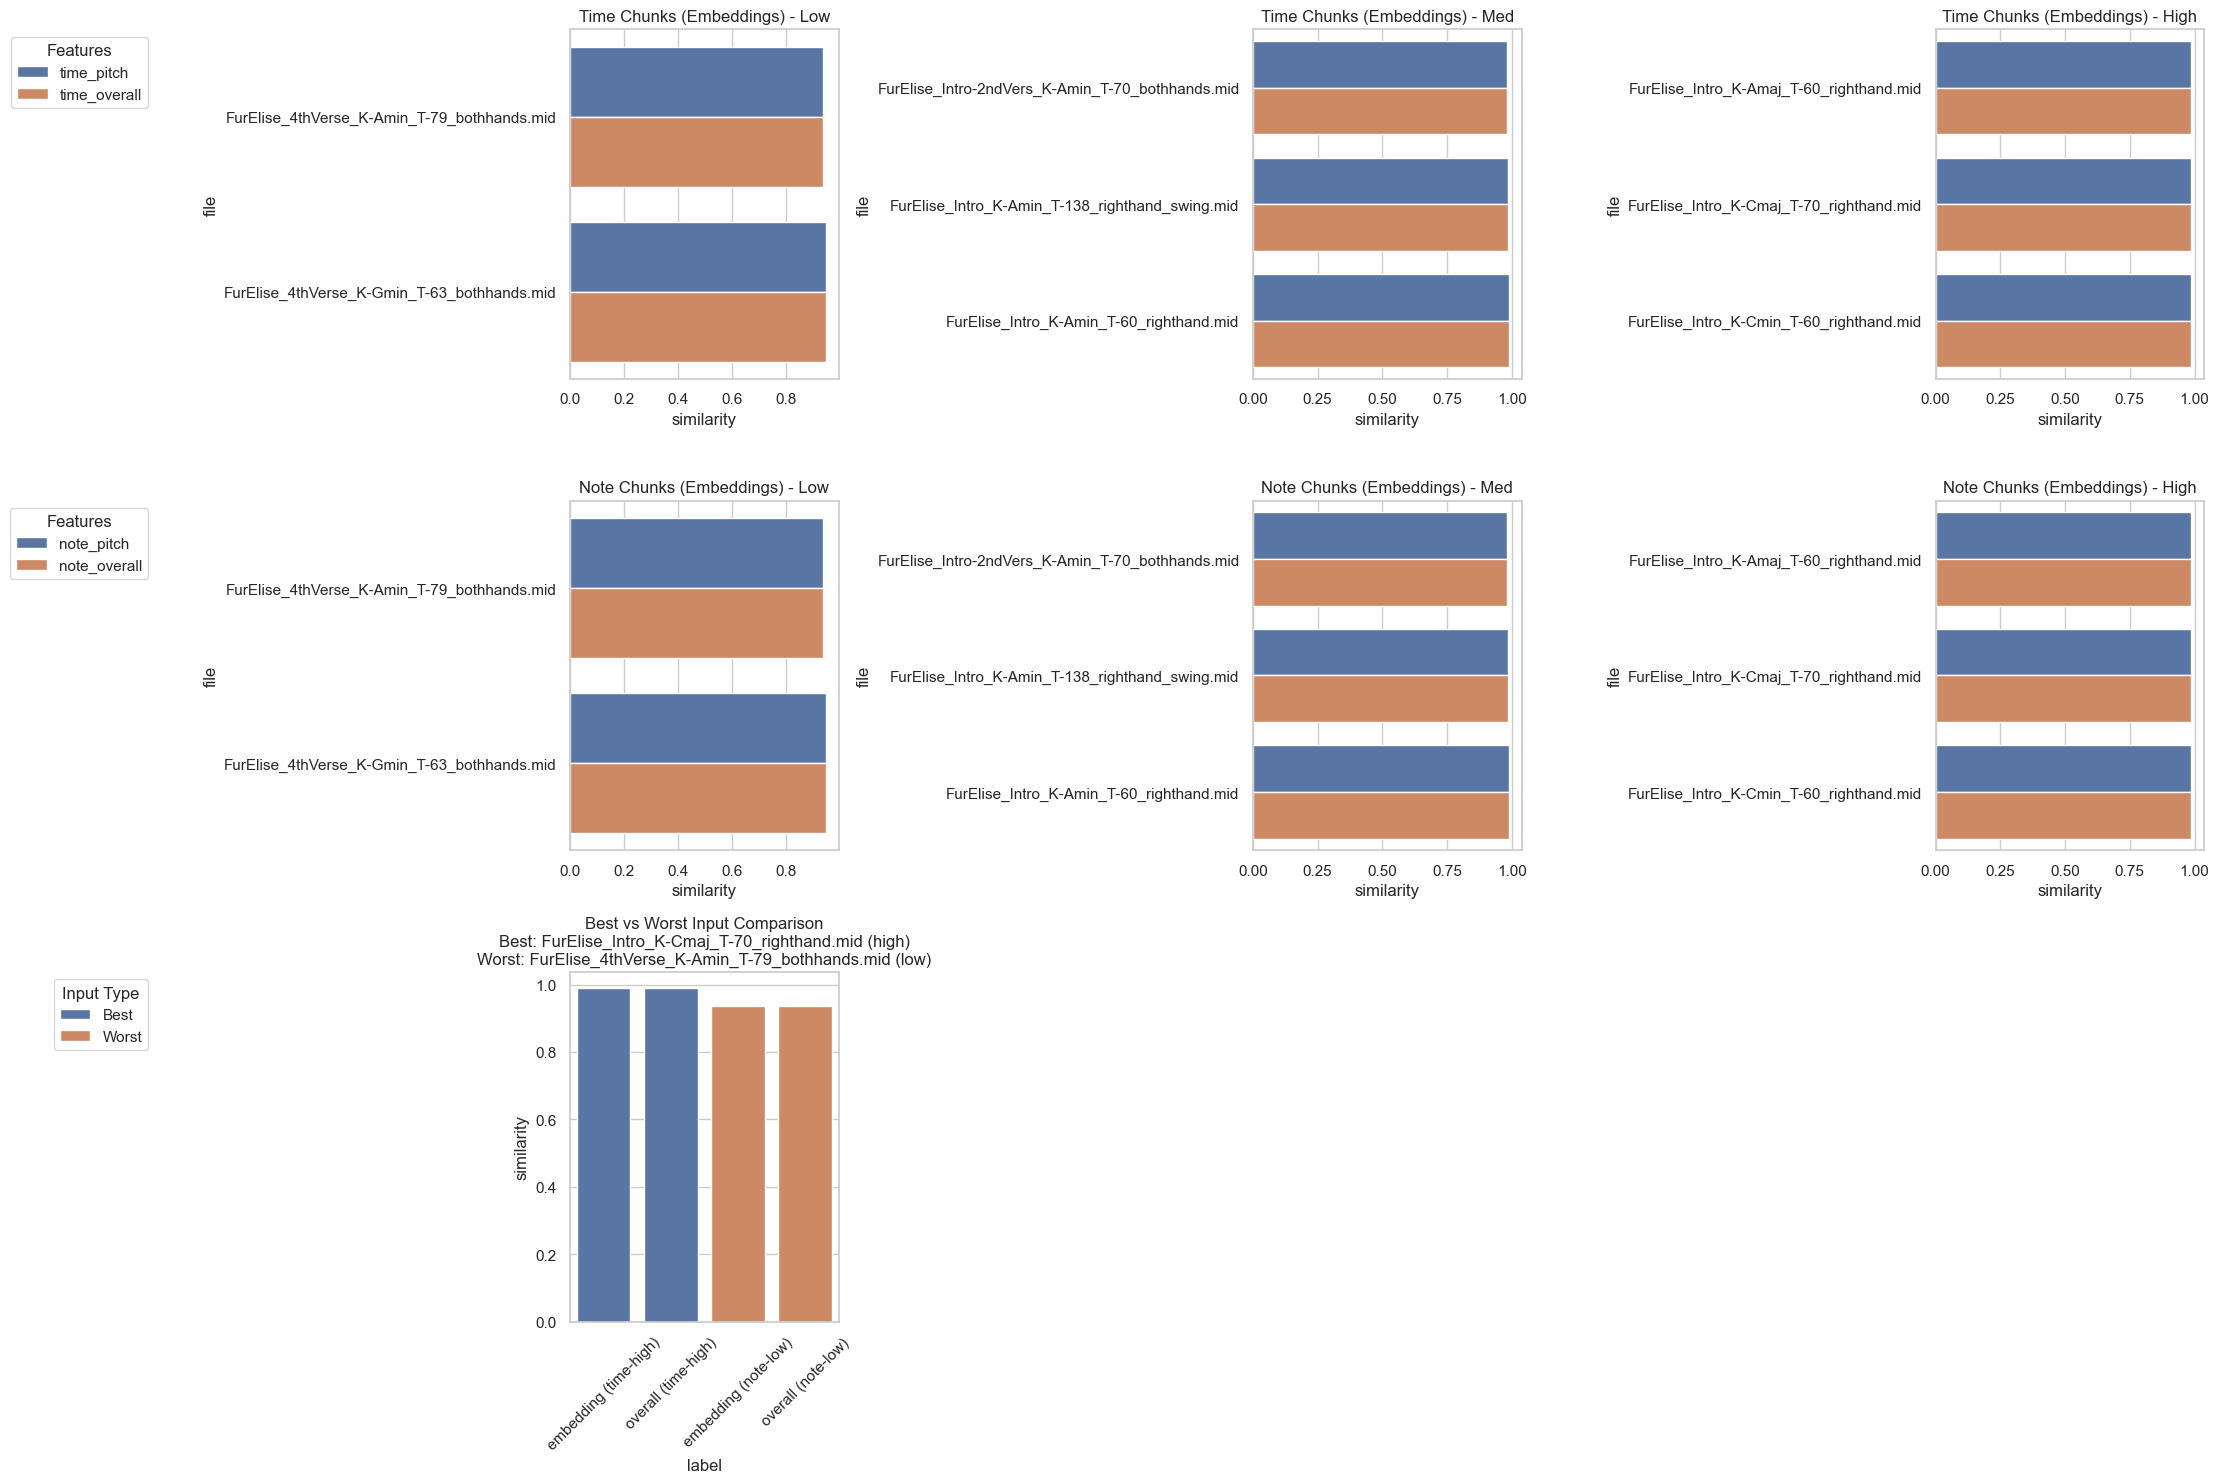

In [16]:
##########################
# Section 4 - Combined plotting with legends only in first column (MusicBERT embeddings)
##########################
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

# Melt for Seaborn
df_time = df.melt(
    id_vars="file",
    value_vars=["time_pitch","time_overall"],
    var_name="feature",
    value_name="similarity"
)

df_note = df.melt(
    id_vars="file",
    value_vars=["note_pitch","note_overall"],
    var_name="feature",
    value_name="similarity"
)

fig, axes = plt.subplots(3, 4, figsize=(22, 15), gridspec_kw={'width_ratios':[0.15,1,1,1]})

# Hide first column axes for legend placeholders
for row in range(3):
    axes[row,0].axis('off')

# Helper: split files by low/med/high
def get_split_files(df, col, split):
    sorted_files = df.sort_values(col)["file"].values
    n = len(sorted_files)

    if split == "low":
        return sorted_files[:n//3]
    elif split == "med":
        return sorted_files[n//3:2*n//3]
    elif split == "high":
        return sorted_files[2*n//3:]
    else:
        return sorted_files


# -----------------------------
# Row 1 - Time chunk embeddings
# -----------------------------
for i, split in enumerate(["low","med","high"]):

    sns.barplot(
        x="similarity",
        y="file",
        hue="feature",
        data=df_time[df_time["file"].isin(get_split_files(df,"time_overall",split))],
        ax=axes[0,i+1]
    )

    axes[0,i+1].set_title(f"Time Chunks (Embeddings) - {split.capitalize()}")
    axes[0,i+1].legend_.remove()

handles, labels = axes[0,1].get_legend_handles_labels()
axes[0,0].legend(handles, labels, title="Features")
axes[0,0].axis('off')


# -----------------------------
# Row 2 - Note chunk embeddings
# -----------------------------
for i, split in enumerate(["low","med","high"]):

    sns.barplot(
        x="similarity",
        y="file",
        hue="feature",
        data=df_note[df_note["file"].isin(get_split_files(df,"note_overall",split))],
        ax=axes[1,i+1]
    )

    axes[1,i+1].set_title(f"Note Chunks (Embeddings) - {split.capitalize()}")
    axes[1,i+1].legend_.remove()

handles, labels = axes[1,1].get_legend_handles_labels()
axes[1,0].legend(handles, labels, title="Features")
axes[1,0].axis('off')


# -----------------------------
# Row 3 - Best vs Worst comparison
# -----------------------------
axes[2,2].axis('off')
axes[2,3].axis('off')

if not df.empty:

    df["overall_avg"] = df[["time_overall","note_overall"]].mean(axis=1)

    best_row = df.loc[df["overall_avg"].idxmax()]
    worst_row = df.loc[df["overall_avg"].idxmin()]

    def get_split_label(row, chunk_type):

        if chunk_type == "time":
            if row["file"] in get_split_files(df,"time_overall","low"):
                return "low"
            elif row["file"] in get_split_files(df,"time_overall","med"):
                return "med"
            else:
                return "high"

        else:
            if row["file"] in get_split_files(df,"note_overall","low"):
                return "low"
            elif row["file"] in get_split_files(df,"note_overall","med"):
                return "med"
            else:
                return "high"

    best_worst_df = pd.DataFrame([
        {"feature":"embedding","similarity":best_row["time_pitch"],"input_type":"Best","chunk":"time","split":get_split_label(best_row,"time")},
        {"feature":"overall","similarity":best_row["time_overall"],"input_type":"Best","chunk":"time","split":get_split_label(best_row,"time")},
        {"feature":"embedding","similarity":worst_row["note_pitch"],"input_type":"Worst","chunk":"note","split":get_split_label(worst_row,"note")},
        {"feature":"overall","similarity":worst_row["note_overall"],"input_type":"Worst","chunk":"note","split":get_split_label(worst_row,"note")},
    ])

    best_worst_df["label"] = best_worst_df["feature"] + " (" + best_worst_df["chunk"] + "-" + best_worst_df["split"] + ")"

    sns.barplot(
        x="label",
        y="similarity",
        hue="input_type",
        data=best_worst_df,
        ax=axes[2,1]
    )

    axes[2,1].set_title(
        f"Best vs Worst Input Comparison\n"
        f"Best: {best_row['file']} ({get_split_label(best_row,'time')})\n"
        f"Worst: {worst_row['file']} ({get_split_label(worst_row,'note')})"
    )

    axes[2,1].tick_params(axis='x', rotation=45)

    handles, labels = axes[2,1].get_legend_handles_labels()
    axes[2,0].legend(handles, labels, title="Input Type")
    axes[2,0].axis('off')

    axes[2,1].legend_.remove()

else:

    axes[2,1].text(0.5,0.5,"No valid MIDI comparisons",ha='center',va='center')
    axes[2,1].axis('off')
    axes[2,0].axis('off')


plt.tight_layout()
plt.show()